# Supply Chain Route Pattern Clustering

**Objective:** Cluster logistics lanes by distance, lead time, cost, variability, handling, and emissions intensity.

The deterministic demo data contains hidden generator profiles for post-hoc diagnostics. Those profiles are never supplied to the clustering algorithms.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic domain-shaped data


In [2]:
FEATURES = ["distance_km", "lead_time_hours", "cost_per_tonne", "delay_std_hours", "handling_events", "co2_kg_per_tonne"]
PROFILE_CENTERS = {
  "regional_road": [
    620,
    18,
    85,
    5,
    3,
    74
  ],
  "ocean_longhaul": [
    8200,
    420,
    54,
    48,
    7,
    38
  ],
  "air_priority": [
    4700,
    17,
    540,
    4,
    5,
    610
  ],
  "rail_corridor": [
    1900,
    58,
    72,
    11,
    4,
    29
  ]
}
rows = []
for profile, centers in PROFILE_CENTERS.items():
    centers = np.asarray(centers, dtype=float)
    scales = np.maximum(np.abs(centers) * 0.10, 0.08)
    samples = rng.normal(centers, scales, size=(125, len(FEATURES)))
    samples = np.maximum(samples, 0)
    for row in samples:
        rows.append({**dict(zip(FEATURES, row)), "generator_profile": profile})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
for column in FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=8, replace=False)
    data.loc[missing_rows, column] = np.nan
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset shape: 500 rows × 7 columns


,distance_km,lead_time_hours,cost_per_tonne,delay_std_hours,handling_events,co2_kg_per_tonne,generator_profile
0,6021.945,14.094,500.128,3.754,4.575,544.267,air_priority
1,579.434,18.770,83.391,5.164,3.109,83.773,regional_road
2,4931.380,15.945,454.563,3.702,4.973,681.106,air_priority
3,8204.934,438.830,60.293,55.907,7.217,40.240,ocean_longhaul
4,649.210,17.040,81.501,5.681,2.688,56.145,regional_road


,count,mean,std,min,25%,50%,75%,max
distance_km,492.0,3880.321,2962.703,436.199,1552.757,3684.476,6159.026,10806.660
lead_time_hours,492.0,127.341,170.866,11.819,17.296,21.760,72.343,517.013
cost_per_tonne,500.0,186.335,203.898,39.681,60.412,79.169,185.621,697.369
delay_std_hours,500.0,17.086,18.413,2.900,4.449,7.272,18.877,61.484
handling_events,500.0,4.744,1.558,2.277,3.366,4.493,5.777,8.610
co2_kg_per_tonne,500.0,185.554,243.164,21.926,32.749,50.418,177.930,781.384


## 3. Robust preprocessing and cluster-count selection


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
X = preprocessor.fit_transform(data[FEATURES])
selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection_rows.append({"k": k, "silhouette": silhouette_score(X, labels), "davies_bouldin": davies_bouldin_score(X, labels)})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))
best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} by maximum silhouette score.")


Selected k=3 by maximum silhouette score.


,k,silhouette,davies_bouldin
0,2,0.7256,0.3903
1,3,0.8519,0.2110
2,4,0.7648,0.3046
3,5,0.6533,0.5946
4,6,0.6688,0.5043


## 4. Compare algorithms and retain the clearer solution


In [4]:
kmeans = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)
hierarchical_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X)

comparison = pd.DataFrame([
    {"model": "K-Means", "silhouette": silhouette_score(X, kmeans_labels), "davies_bouldin": davies_bouldin_score(X, kmeans_labels)},
    {"model": "Agglomerative", "silhouette": silhouette_score(X, hierarchical_labels), "davies_bouldin": davies_bouldin_score(X, hierarchical_labels)},
])
display(comparison.round(4))
labels = kmeans_labels if comparison.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["model"] == "K-Means" else hierarchical_labels
selected_model = "K-Means" if np.array_equal(labels, kmeans_labels) else "Agglomerative"
data["cluster"] = labels
print(f"Selected solution: {selected_model}")


Selected solution: K-Means


,model,silhouette,davies_bouldin
0,K-Means,0.8519,0.211
1,Agglomerative,0.8519,0.211


## 5. Profile and visualize the discovered groups


Retrospective ARI against hidden generator profiles: 0.6936


,records,distance_km,lead_time_hours,cost_per_tonne,delay_std_hours,handling_events,co2_kg_per_tonne
cluster,,,,,,,
0,253,1349.203,37.610,78.206,8.497,3.541,51.110
1,122,8246.238,420.715,53.566,48.319,7.026,38.064
2,125,4606.234,16.881,534.769,3.985,4.953,601.620


cluster,0,1,2,All
generator_profile,,,,
air_priority,0,0,125,125
ocean_longhaul,3,122,0,125
rail_corridor,125,0,0,125
regional_road,125,0,0,125
All,253,122,125,500


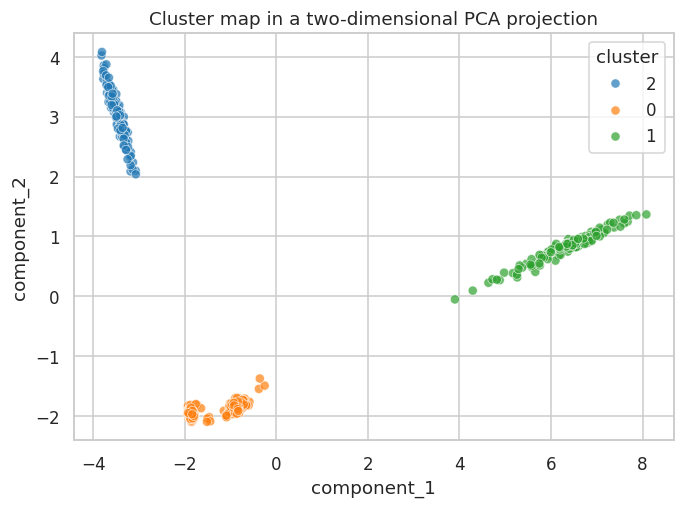

In [5]:
from sklearn.decomposition import PCA

profiles = data.groupby("cluster")[FEATURES].mean().round(3)
profiles.insert(0, "records", data.groupby("cluster").size())
display(profiles)
display(pd.crosstab(data["generator_profile"], data["cluster"], margins=True))
print(f"Retrospective ARI against hidden generator profiles: {adjusted_rand_score(data['generator_profile'], data['cluster']):.4f}")

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("Cluster map in a two-dimensional PCA projection")
plt.tight_layout()
plt.show()


## 6. Stability and assignment example


In [6]:
alternate = KMeans(n_clusters=best_k, n_init=40, random_state=7).fit_predict(X)
print(f"K-Means stability across seeds (ARI): {adjusted_rand_score(kmeans_labels, alternate):.4f}")
if selected_model == "K-Means":
    example = data[FEATURES].median().to_frame().T
    predicted = int(kmeans.predict(preprocessor.transform(example))[0])
    display(example.round(3).assign(predicted_cluster=predicted))
else:
    print("Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.")


K-Means stability across seeds (ARI): 1.0000


,distance_km,lead_time_hours,cost_per_tonne,delay_std_hours,handling_events,co2_kg_per_tonne,predicted_cluster
0,3684.476,21.76,79.169,7.272,4.493,50.418,0


## 7. Findings and limitations

- Multiple internal metrics and a seed-stability check are used because clustering has no single accuracy measure.
- Hidden generator profiles provide only a retrospective pipeline check.
- Production interpretation requires domain validation, drift monitoring, and explicit rules for acting on segments.
